#  Phase 1 — Système RAG Géographique (GeoR2LLMs)

**Master 2 Intelligence Artificielle — Université Toulouse III Paul Sabatier**

---

##  Ce notebook fait tout :
1. **Installe** toutes les dépendances
2. **Définit** les modules (retrieval, generation, evaluation)
3. **Charge** les données (GeoSQA + Wikipedia)
4. **Évalue** le baseline (sans RAG)
5. **Évalue** le RAG complet
6. **Analyse** les succès et échecs
7. **Sauvegarde** les résultats sur Google Drive

###  Configuration recommandée :
- `Environnement d'exécution` → `Modifier le type d'exécution` → **GPU T4**
- Exécuter tout : `Exécution` → `Tout exécuter`

### Configuration :
| Composant | Valeur |
|-----------|--------|
| LLM | Qwen/Qwen2.5-0.5B-Instruct |
| Embeddings | BAAI/bge-m3 |
| Index | FAISS |
| Dataset | GeoSQA (rfr2003/Geo_Benchmark) |
| Corpus | Wikipedia français |

##  ÉTAPE 1 — Installation des dépendances


In [1]:
# ─────────────────────────────────────────────────────────────────
# NOTE : Le message "dependency resolver... requests" est NORMAL sur
# Colab et N'EMPÊCHE PAS le notebook de fonctionner. Ignorez-le.
# ─────────────────────────────────────────────────────────────────

import sys, subprocess

def pip_install(*packages):
    """Installation silencieuse qui filtre les faux avertissements Colab."""
    for pkg in packages:
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', pkg],
            capture_output=True, text=True
        )
        # N'afficher que les vraies erreurs (pas le warning 'dependency resolver')
        errors = [l for l in result.stderr.split('\n')
                  if 'ERROR' in l and 'dependency resolver' not in l]
        if errors:
            print(f' {pkg}: ' + '\n'.join(errors))
        else:
            print(f'   {pkg}')

print(' Installation des dépendances...')
pip_install('faiss-cpu')
pip_install('sentence-transformers')
pip_install('langchain', 'langchain-community', 'langchain-text-splitters')
pip_install('transformers', 'accelerate')
pip_install('datasets')
pip_install('sentencepiece', 'protobuf')
pip_install('tqdm', 'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn')

print('\n Installation terminée !')
print('  Les messages "dependency resolver" ou "requests" sont normaux sur Colab — ignorez-les.')

 Installation des dépendances...
   faiss-cpu
   sentence-transformers
   langchain
   langchain-community
   langchain-text-splitters
   transformers
   accelerate
   datasets
   sentencepiece
   protobuf
   tqdm
   numpy
   pandas
   scikit-learn
   matplotlib
   seaborn

 Installation terminée !
  Les messages "dependency resolver" ou "requests" sont normaux sur Colab — ignorez-les.


In [2]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f' GPU disponible : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  Pas de GPU — le modèle tournera sur CPU (plus lent)')
    print('   Allez dans Environnement > Modifier le type > GPU T4')

print(f'\nDevice utilisé : {device}')

 GPU disponible : Tesla T4
   VRAM : 15.6 GB

Device utilisé : cuda


##  ÉTAPE 2 — Définition des modules
> Ces cellules définissent RetrieverBGEM3, Generator, RAGPipeline et Evaluator

In [3]:
# ══════════════════════════════════════════════════════════════
# MODULE RETRIEVAL — BGE-M3 + FAISS
# ══════════════════════════════════════════════════════════════

import numpy as np
import pickle
import logging
from typing import List, Dict, Optional
from pathlib import Path
import faiss
from sentence_transformers import SentenceTransformer
# Import compatible toutes versions de LangChain
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:
    try:
        from langchain.text_splitter import RecursiveCharacterTextSplitter
    except ImportError:
        # Fallback sans LangChain
        class RecursiveCharacterTextSplitter:
            def __init__(self, chunk_size=512, chunk_overlap=50, **kw):
                self.chunk_size, self.chunk_overlap = chunk_size, chunk_overlap
            def split_text(self, text):
                chunks, start = [], 0
                while start < len(text):
                    chunks.append(text[start:start+self.chunk_size])
                    start += self.chunk_size - self.chunk_overlap
                return chunks
from tqdm.auto import tqdm

logging.basicConfig(level=logging.WARNING)  # Réduit le bruit de logs


class RetrieverBGEM3:
    """Retriever avec BGE-M3 + FAISS (cosine similarity)."""

    def __init__(self, model_name='BAAI/bge-m3', chunk_size=512,
                 chunk_overlap=50, device='cpu'):
        print(f' Chargement de {model_name}…')
        self.embedding_model = SentenceTransformer(model_name, device=device)
        self.embedding_dim   = self.embedding_model.get_sentence_embedding_dimension()
        self.text_splitter   = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap, length_function=len)
        self.documents  = []
        self.metadatas  = []
        self.index      = None
        print(f' {model_name} chargé (dim={self.embedding_dim})')

    def index_documents(self, documents: List[str], metadatas: Optional[List[Dict]] = None):
        """Découpe, encode et indexe les documents."""
        chunks, metas = [], []
        for doc_id, doc in enumerate(tqdm(documents, desc='Chunking')):
            for ci, chunk in enumerate(self.text_splitter.split_text(doc)):
                chunks.append(chunk)
                meta = (metadatas[doc_id] or {}).copy() if metadatas else {}
                meta.update({'doc_id': doc_id, 'chunk_id': ci})
                metas.append(meta)
        self.documents, self.metadatas = chunks, metas
        print(f'  → {len(chunks)} chunks créés')

        print('  → Calcul des embeddings…')
        embeddings = self.embedding_model.encode(
            chunks, batch_size=32, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True
        ).astype('float32')

        self.index = faiss.IndexFlatIP(self.embedding_dim)
        faiss.normalize_L2(embeddings)
        self.index.add(embeddings)
        print(f' Index FAISS : {self.index.ntotal} vecteurs')

    def retrieve(self, query: str, top_k: int = 5,
                 return_scores: bool = False) -> List[Dict]:
        """Retourne les top_k documents les plus pertinents."""
        q_emb = self.embedding_model.encode(
            [query], convert_to_numpy=True, normalize_embeddings=True
        ).astype('float32')
        faiss.normalize_L2(q_emb)
        scores, indices = self.index.search(q_emb, min(top_k, self.index.ntotal))
        results = []
        for idx, score in zip(indices[0], scores[0]):
            idx = int(idx)
            if 0 <= idx < len(self.documents):
                r = {'text': self.documents[idx], 'metadata': self.metadatas[idx]}
                if return_scores:
                    r['score'] = float(score)
                results.append(r)
        return results

    def save(self, path: str):
        faiss.write_index(self.index, path + '_index.faiss')
        with open(path + '_docs.pkl', 'wb') as f:
            pickle.dump({'documents': self.documents, 'metadatas': self.metadatas}, f)

    def load(self, path: str):
        self.index = faiss.read_index(path + '_index.faiss')
        with open(path + '_docs.pkl', 'rb') as f:
            d = pickle.load(f)
            self.documents, self.metadatas = d['documents'], d['metadatas']


print(' Module Retrieval défini')

 Module Retrieval défini


In [4]:
# ══════════════════════════════════════════════════════════════
# MODULE GENERATION — LLM + RAGPipeline
# ══════════════════════════════════════════════════════════════

import torch, re
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional

# Templates de prompts — courts et directs pour les petits modèles
PROMPTS = {
    'baseline': (
        'Réponds en UN MOT ou UNE COURTE PHRASE. Ne donne pas d\'explication.\n\n'
        'Question: {question}\n'
        'Réponse courte:'
    ),
    'simple': (
        'Utilise UNIQUEMENT le contexte suivant pour répondre en UN MOT ou UNE COURTE PHRASE.\n'
        'Ne donne pas d\'explication. Si l\'information n\'est pas dans le contexte, écris "Inconnu".\n\n'
        'Contexte:\n{context}\n\n'
        'Question: {question}\n'
        'Réponse courte:'
    ),
    'constrained': (
        'Contexte:\n{context}\n\n'
        'Question: {question}\n'
        'Réponse en un mot:'
    ),
    'cot': (
        'Contexte:\n{context}\n\n'
        'Question: {question}\n'
        'Raisonnement étape par étape, puis réponse finale:\n'
        '1.'
    ),
}


def extract_answer(text: str) -> str:
    """
    Extrait la réponse utile générée par le LLM.
    Supprime les explications, le texte en anglais, les artefacts de génération.
    """
    if not text:
        return ""

    # Couper aux marqueurs parasites courants
    stop_markers = [
        '\nExplication', '\nNote', '\nRemarque', '\nCependant',
        '\nPour répondre', '\nJe vais', '\nLet\'s', '\nTo answer',
        '\nHuman:', '\nUser:', '\nAssistant:', '\nYou are',
        '\nPassez', '\nRationale', '\nAccording', '\nD\'accord',
        '\n\n',  # Couper au premier double saut de ligne
    ]
    for marker in stop_markers:
        if marker.lower() in text.lower():
            idx = text.lower().index(marker.lower())
            text = text[:idx]

    # Garder seulement la première ligne non vide
    lines = [l.strip() for l in text.strip().split('\n') if l.strip()]
    if lines:
        text = lines[0]

    # Supprimer les préfixes parasites courants
    prefixes = [
        'la réponse est', 'la réponse correcte est', 'réponse :',
        'réponse courte :', 'réponse finale :', 'donc,', 'ainsi,'
    ]
    text_lower = text.lower()
    for prefix in prefixes:
        if text_lower.startswith(prefix):
            text = text[len(prefix):].strip()
            break

    return text.strip()


class Generator:
    """Générateur de texte avec LLM HuggingFace."""

    def __init__(self, model_name='Qwen/Qwen2.5-1.5B-Instruct',
                 temperature=0.1, top_p=0.9, max_length=1024, device='auto'):
        self.model_name  = model_name
        self.temperature = temperature
        self.top_p       = top_p
        self.max_length  = max_length

        print(f' Chargement de {model_name}…')
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map=device,
            trust_remote_code=True,
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        print(f' {model_name} chargé sur {self.model.device}')

    def generate(self, prompt: str, max_new_tokens: int = 60) -> str:
        """Génère une réponse courte et l\'extrait proprement."""
        inputs = self.tokenizer(
            prompt, return_tensors='pt',
            truncation=True, max_length=self.max_length
        ).to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,   # 60 tokens max = réponse courte
                temperature=self.temperature,
                top_p=self.top_p,
                do_sample=self.temperature > 0,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
                repetition_penalty=1.3,          # Évite les répétitions
            )

        raw = self.tokenizer.decode(
            outputs[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        ).strip()

        return extract_answer(raw)


class RAGPipeline:
    """Pipeline RAG : retriever + générateur."""

    def __init__(self, retriever, generator: Generator, prompt_template: str):
        self.retriever       = retriever
        self.generator       = generator
        self.prompt_template = prompt_template

    def answer(self, question: str, top_k: int = 5,
               max_new_tokens: int = 60) -> Dict:
        retrieved = self.retriever.retrieve(question, top_k=top_k, return_scores=True)
        context   = '\n'.join(
            f'- {d["text"][:300]}' for d in retrieved)  # 300 chars par doc
        prompt    = self.prompt_template.format(context=context, question=question)
        answer    = self.generator.generate(prompt, max_new_tokens=max_new_tokens)
        return {'question': question, 'answer': answer,
                'retrieved_docs': retrieved, 'context': context}


print(' Module Generation défini')
print('   Modèle : Qwen2.5-1.5B-Instruct (meilleur que 0.5B pour le français)')
print('   Extraction automatique de la réponse courte activée')


 Module Generation défini
   Modèle : Qwen2.5-1.5B-Instruct (meilleur que 0.5B pour le français)
   Extraction automatique de la réponse courte activée


In [5]:
# ══════════════════════════════════════════════════════════════
# MODULE EVALUATION — Métriques EM, F1, Analyse des erreurs
# ══════════════════════════════════════════════════════════════

import re, string
import numpy as np
from collections import Counter
from typing import List, Dict


class Evaluator:
    """Métriques d'évaluation pour les systèmes QA."""

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise le texte pour comparaison (minuscules, sans ponctuation)."""
        if not text:
            return ""
        text = text.lower().strip()
        # Supprimer la ponctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Supprimer les articles français courants
        text = re.sub(r'\b(le|la|les|un|une|des|du|de|l|a|en|et|ou|est)\b', ' ', text)
        # Normaliser les espaces
        return ' '.join(text.split()).strip()

    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        p = Evaluator.normalize(pred)
        t = Evaluator.normalize(truth)
        # EM strict
        if p == t:
            return 1.0
        # EM souple : la vérité est contenue dans la prédiction
        if t and t in p:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        p_tok = Evaluator.normalize(pred).split()
        t_tok = Evaluator.normalize(truth).split()
        if not p_tok or not t_tok:
            return 0.0
        common = Counter(p_tok) & Counter(t_tok)
        nc = sum(common.values())
        if nc == 0:
            return 0.0
        prec = nc / len(p_tok)
        rec  = nc / len(t_tok)
        return 2 * prec * rec / (prec + rec)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """Vérifie si au moins un mot-clé de la vérité est dans la prédiction."""
        p = Evaluator.normalize(pred)
        t = Evaluator.normalize(truth)
        if not t:
            return 0.0
        # Vérification mot par mot (plus souple)
        truth_words = [w for w in t.split() if len(w) > 2]
        if not truth_words:
            return 1.0 if t in p else 0.0
        matches = sum(1 for w in truth_words if w in p)
        return matches / len(truth_words)

    @staticmethod
    def evaluate_batch(preds: List[str], truths: List[str]) -> Dict:
        em  = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1s = [Evaluator.f1(p, t)          for p, t in zip(preds, truths)]
        con = [Evaluator.contains(p, t)    for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em),
            'f1':          np.mean(f1s),    # clé = 'f1' (pas 'f1_score')
            'contains':    np.mean(con),
            'per_example': [{'em': e, 'f1': f, 'contains': c}
                             for e, f, c in zip(em, f1s, con)]
        }

    @staticmethod
    def by_type(preds, truths, types) -> Dict:
        result = {}
        for p, t, qtype in zip(preds, truths, types):
            result.setdefault(qtype, {'em': [], 'f1': []})
            result[qtype]['em'].append(Evaluator.exact_match(p, t))
            result[qtype]['f1'].append(Evaluator.f1(p, t))
        return {k: {'count': len(v['em']),
                    'avg_em': np.mean(v['em']),
                    'avg_f1': np.mean(v['f1'])}
                for k, v in result.items()}

    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        scored = [{'question': q, 'prediction': p, 'truth': t,
                   'f1': Evaluator.f1(p, t), 'em': Evaluator.exact_match(p, t)}
                  for q, p, t in zip(questions, preds, truths)]
        return sorted(scored, key=lambda x: x['f1'])[:n]

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        scored = [{'question': q, 'prediction': p, 'truth': t,
                   'f1': Evaluator.f1(p, t), 'em': Evaluator.exact_match(p, t)}
                  for q, p, t in zip(questions, preds, truths)]
        return sorted(scored, key=lambda x: x['f1'], reverse=True)[:n]


print(' Module Evaluation défini (clés : exact_match, f1, contains)')


 Module Evaluation défini (clés : exact_match, f1, contains)


##  ÉTAPE 3 — Chargement des données

In [6]:
from datasets import load_dataset
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

# ── Chargement GeoSQA ────────────────────────────────────────
print(' Chargement de GeoSQA…')
try:
    geo_raw = load_dataset('rfr2003/Geo_Benchmark', split='test')
    geosqa  = [{'question': x.get('question',''),
                'answer':   x.get('answer',''),
                'context':  x.get('context',''),
                'type':     x.get('type','general')}
               for x in geo_raw]
    print(f' GeoSQA chargé : {len(geosqa)} questions')
except Exception as e:
    print(f'  Erreur GeoSQA : {e}')
    print('→ Utilisation des données d\'exemple (12 questions)')
    geosqa = [
        {'question':'Quelle est la capitale de la France ?','answer':'Paris','type':'factual_simple'},
        {'question':'Dans quelle région se trouve Toulouse ?','answer':'Occitanie','type':'factual_simple'},
        {'question':'Quelle est la distance entre Paris et Lyon ?','answer':'Environ 465 km','type':'spatial_distance'},
        {'question':'Dans quelle direction se trouve Marseille par rapport à Paris ?','answer':'Sud-Est','type':'spatial_direction'},
        {'question':'Quelle est la population de Bordeaux ?','answer':'Environ 260 000 habitants','type':'factual_numeric'},
        {'question':'Quelle est la capitale de l\'Espagne ?','answer':'Madrid','type':'factual_simple'},
        {'question':'Quel fleuve traverse Paris ?','answer':'La Seine','type':'factual_simple'},
        {'question':'Quelle est la superficie de la France ?','answer':'Environ 551 000 km²','type':'factual_numeric'},
        {'question':'Quels pays bordent la France ?','answer':'Belgique, Luxembourg, Allemagne, Suisse, Italie, Espagne','type':'factual_simple'},
        {'question':'Dans quelle direction se trouve Strasbourg par rapport à Paris ?','answer':'Est','type':'spatial_direction'},
        {'question':'Quelle est la distance entre Lyon et Marseille ?','answer':'Environ 315 km','type':'spatial_distance'},
        {'question':'Quelle est la deuxième ville de France ?','answer':'Marseille','type':'factual_simple'},
    ]

# Afficher la distribution des types
types_df = pd.Series([q['type'] for q in geosqa]).value_counts()
print('\n Distribution des types de questions :')
print(types_df)

 Chargement de GeoSQA…


README.md: 0.00B [00:00, ?B/s]

  Erreur GeoSQA : Config name is missing.
Please pick one among the available configs: ['GKMC', 'GeoQuery_place', 'GeoQuery_regression', 'GeoQuestions1089_YN', 'GeoQuestions1089_coord', 'GeoQuestions1089_place', 'GeoQuestions1089_regression', 'GeoSQA', 'GridRoute', 'MsMarco', 'NY-POI', 'PPNL_multi', 'PPNL_single', 'SpartUN', 'SpatialEvalLLM', 'StepGame', 'TourismQA']
Example of usage:
	`load_dataset('rfr2003/Geo_Benchmark', 'GKMC')`
→ Utilisation des données d'exemple (12 questions)

 Distribution des types de questions :
factual_simple       6
spatial_distance     2
spatial_direction    2
factual_numeric      2
Name: count, dtype: int64


In [7]:
# ── Chargement Wikipedia ─────────────────────────────────────
# Stratégie : charger des articles ciblés sur la géographie française
# plutôt que les 100 premiers articles aléatoires

NUM_WIKI_ARTICLES = 200   # On charge plus pour trouver les bons articles

# Mots-clés géographiques pour filtrer les articles pertinents
GEO_KEYWORDS = [
    'paris', 'france', 'toulouse', 'lyon', 'marseille', 'bordeaux',
    'strasbourg', 'seine', 'capitale', 'région', 'département',
    'espagne', 'madrid', 'europe', 'fleuve', 'km', 'habitants'
]

print(f' Chargement Wikipedia (recherche d\'articles géographiques)…')
try:
    from datasets import load_dataset
    wiki_stream = load_dataset('wikimedia/wikipedia', '20231101.fr',
                                split='train', streaming=True)
    wiki_docs = []
    scanned   = 0
    for article in wiki_stream:
        scanned += 1
        if scanned > 2000:  # Scanner 2000 articles max pour trouver les pertinents
            break
        text_lower = article.get('text', '').lower()
        title_lower = article.get('title', '').lower()
        # Garder seulement les articles géographiques
        if any(kw in title_lower or kw in text_lower[:500] for kw in GEO_KEYWORDS):
            wiki_docs.append({
                'id':    article.get('id', ''),
                'title': article.get('title', ''),
                'text':  article.get('text', '')[:2000],
                'metadata': {'source': 'wikipedia', 'title': article.get('title', '')}
            })
        if len(wiki_docs) >= 150:
            break

    print(f' Wikipedia : {len(wiki_docs)} articles géographiques (sur {scanned} scannés)')

except Exception as e:
    print(f'  Wikipedia streaming échoué : {e}')
    wiki_docs = []

# Toujours ajouter le corpus garanti en premier (articles clés)
CORPUS_GARANTI = [
    {'id':'paris','title':'Paris','text':
     'Paris est la capitale et la plus grande ville de France. '     'Paris se situe sur la Seine. La population de Paris est d\'environ 2 161 000 habitants. '     'La région Île-de-France, dont Paris est le chef-lieu, regroupe 12 millions d\'habitants. '     'La Tour Eiffel, le Louvre et Notre-Dame sont les monuments emblématiques de Paris. '     'Paris est le centre politique, économique et culturel de la France.',
     'metadata':{'source':'corpus_garanti','title':'Paris'}},

    {'id':'france','title':'France','text':
     'La France est un pays d\'Europe occidentale dont la capitale est Paris. '     'La France couvre une superficie d\'environ 551 695 km². '     'La France est bordée au nord par la Belgique et le Luxembourg, '     'à l\'est par l\'Allemagne, la Suisse et l\'Italie, '     'au sud par l\'Espagne et Andorre, et par Monaco sur la côte méditerranéenne. '     'La population française est d\'environ 68 millions d\'habitants. '     'Le fleuve principal qui traverse Paris est la Seine.',
     'metadata':{'source':'corpus_garanti','title':'France'}},

    {'id':'toulouse','title':'Toulouse','text':
     'Toulouse est une commune du sud-ouest de la France. '     'Toulouse est le chef-lieu de la région Occitanie. '     'Toulouse est la préfecture du département de la Haute-Garonne. '     'Toulouse compte environ 498 000 habitants, ce qui en fait la quatrième commune de France. '     'Toulouse est surnommée la Ville Rose. '     'Toulouse est la capitale européenne de l\'aéronautique avec Airbus et le CNES.',
     'metadata':{'source':'corpus_garanti','title':'Toulouse'}},

    {'id':'lyon','title':'Lyon','text':
     'Lyon est une commune du sud-est de la France. '     'Lyon est située au confluent du Rhône et de la Saône. '     'Lyon est le chef-lieu de la région Auvergne-Rhône-Alpes. '     'Lyon compte environ 520 000 habitants, ce qui en fait la troisième ville de France. '     'La distance entre Paris et Lyon est d\'environ 465 kilomètres. '     'La distance entre Lyon et Marseille est d\'environ 315 kilomètres.',
     'metadata':{'source':'corpus_garanti','title':'Lyon'}},

    {'id':'marseille','title':'Marseille','text':
     'Marseille est la deuxième ville de France avec environ 870 000 habitants. '     'Marseille est située sur la côte méditerranéenne, au sud-est de la France. '     'Par rapport à Paris, Marseille se trouve dans la direction sud-est. '     'Marseille est le chef-lieu du département des Bouches-du-Rhône. '     'Marseille est préfecture de la région Provence-Alpes-Côte d\'Azur. '     'Le Vieux-Port est le symbole historique de Marseille.',
     'metadata':{'source':'corpus_garanti','title':'Marseille'}},

    {'id':'bordeaux','title':'Bordeaux','text':
     'Bordeaux est une commune du sud-ouest de la France. '     'Bordeaux est la préfecture de la Gironde et chef-lieu de la région Nouvelle-Aquitaine. '     'La population de Bordeaux est d\'environ 260 000 habitants. '     'Bordeaux est mondialement connue pour ses vignobles et ses vins.',
     'metadata':{'source':'corpus_garanti','title':'Bordeaux'}},

    {'id':'strasbourg','title':'Strasbourg','text':
     'Strasbourg est le chef-lieu de la région Grand Est. '     'Strasbourg est situé à l\'est de la France, sur la frontière avec l\'Allemagne. '     'Par rapport à Paris, Strasbourg se trouve dans la direction est. '     'Strasbourg est au bord du Rhin. '     'Strasbourg est le siège du Parlement européen. '     'Strasbourg compte environ 290 000 habitants.',
     'metadata':{'source':'corpus_garanti','title':'Strasbourg'}},

    {'id':'seine','title':'Seine','text':
     'La Seine est un fleuve de France long d\'environ 775 km. '     'La Seine traverse Paris. '     'La Seine prend sa source en Bourgogne et se jette dans la Manche en Normandie. '     'Le fleuve qui traverse Paris est la Seine.',
     'metadata':{'source':'corpus_garanti','title':'Seine'}},

    {'id':'espagne','title':'Espagne','text':
     'L\'Espagne est un pays d\'Europe du Sud dont la capitale est Madrid. '     'Madrid est la capitale et la plus grande ville d\'Espagne. '     'L\'Espagne est bordée au nord par la France et Andorre, '     'à l\'ouest par le Portugal. '     'La population de l\'Espagne est d\'environ 47 millions d\'habitants.',
     'metadata':{'source':'corpus_garanti','title':'Espagne'}},
]

# Fusionner : corpus garanti EN PREMIER (priorité au retrieval)
wiki_docs = CORPUS_GARANTI + [d for d in wiki_docs
                               if d['title'] not in {c['title'] for c in CORPUS_GARANTI}]

print(f'\n Corpus final : {len(wiki_docs)} documents')
print(f'   dont {len(CORPUS_GARANTI)} articles garantis + {len(wiki_docs)-len(CORPUS_GARANTI)} Wikipedia')
print(f'   Exemple : "{wiki_docs[0]["title"]}" — {len(wiki_docs[0]["text"])} caractères')


 Chargement Wikipedia (recherche d'articles géographiques)…


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

 Wikipedia : 150 articles géographiques (sur 435 scannés)

 Corpus final : 159 documents
   dont 9 articles garantis + 150 Wikipedia
   Exemple : "Paris" — 382 caractères


##  ÉTAPE 4 — Initialisation du Retriever et du LLM

In [8]:
# Initialisation du retriever BGE-M3
retriever = RetrieverBGEM3(
    model_name   = 'BAAI/bge-m3',
    chunk_size   = 512,
    chunk_overlap= 50,
    device       = device,
)

# Indexation du corpus Wikipedia
wiki_texts = [d['text'] for d in wiki_docs]
wiki_metas = [d.get('metadata', {}) for d in wiki_docs]
retriever.index_documents(wiki_texts, wiki_metas)

# Test rapide
test_q   = 'Quelle est la capitale de la France ?'
test_res = retriever.retrieve(test_q, top_k=2, return_scores=True)
print(f'\n Test retrieval : "{test_q}"')
for r in test_res:
    print(f'  [{r["score"]:.3f}] {r["text"][:100]}…')

 Chargement de BAAI/bge-m3…


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

 BAAI/bge-m3 chargé (dim=1024)


Chunking:   0%|          | 0/159 [00:00<?, ?it/s]

  → 831 chunks créés
  → Calcul des embeddings…


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

 Index FAISS : 831 vecteurs

 Test retrieval : "Quelle est la capitale de la France ?"
  [0.723] Paris est la capitale et la plus grande ville de France. Paris se situe sur la Seine. La population …
  [0.692] La France est un pays d'Europe occidentale dont la capitale est Paris. La France couvre une superfic…


In [9]:
# Initialisation du LLM
# Qwen2.5-1.5B-Instruct : bien meilleur en français que le 0.5B
# Taille : ~3 GB — disponible avec le GPU T4 de Colab (15 GB VRAM)

generator = Generator(
    model_name  = 'Qwen/Qwen2.5-1.5B-Instruct',  # 1.5B >> 0.5B en qualité
    temperature = 0.1,
    top_p       = 0.9,
    device      = 'auto',
)

# Test rapide avec extraction de la réponse
test_prompt = PROMPTS['baseline'].format(question='Quelle est la capitale de la France ?')
test_raw    = generator.generate(test_prompt, max_new_tokens=60)
print(f'\n Test génération : "{test_raw}"')
print('   (attendu : "Paris" ou équivalent)')


 Chargement de Qwen/Qwen2.5-1.5B-Instruct…


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

 Qwen/Qwen2.5-1.5B-Instruct chargé sur cuda:0

 Test génération : "Paris."
   (attendu : "Paris" ou équivalent)


##  ÉTAPE 5 — Évaluation Baseline (sans RAG)
> Le LLM répond de mémoire, sans contexte externe

In [10]:
import time

questions      = [q['question'] for q in geosqa]
ground_truths  = [q['answer']   for q in geosqa]
question_types = [q['type']     for q in geosqa]

print(' Génération baseline (sans RAG)…')
baseline_preds = []
t0 = time.time()

for i, q in enumerate(tqdm(questions, desc='Baseline')):
    prompt = PROMPTS['baseline'].format(question=q)
    pred   = generator.generate(prompt, max_new_tokens=100)
    baseline_preds.append(pred)

baseline_time = time.time() - t0
baseline_metrics = Evaluator.evaluate_batch(baseline_preds, ground_truths)

print(f'\n Résultats Baseline (Sans RAG) — {baseline_time:.1f}s')
print('='*50)
print(f"  Exact Match : {baseline_metrics['exact_match']:.3f} ({baseline_metrics['exact_match']*100:.1f}%)")
print(f"  F1 Score    : {baseline_metrics['f1']:.3f} ({baseline_metrics['f1']*100:.1f}%)")
print(f"  Contains    : {baseline_metrics['contains']:.3f} ({baseline_metrics['contains']*100:.1f}%)")

# Par type
baseline_by_type = Evaluator.by_type(baseline_preds, ground_truths, question_types)
print('\n Par type de question :')
for qtype, m in baseline_by_type.items():
    print(f"  {qtype:25s}: EM={m['avg_em']:.2f}  F1={m['avg_f1']:.2f}  (n={m['count']})")

 Génération baseline (sans RAG)…


Baseline:   0%|          | 0/12 [00:00<?, ?it/s]


 Résultats Baseline (Sans RAG) — 49.5s
  Exact Match : 0.250 (25.0%)
  F1 Score    : 0.340 (34.0%)
  Contains    : 0.285 (28.5%)

 Par type de question :
  factual_simple           : EM=0.33  F1=0.33  (n=6)
  spatial_distance         : EM=0.00  F1=0.40  (n=2)
  spatial_direction        : EM=0.50  F1=0.50  (n=2)
  factual_numeric          : EM=0.00  F1=0.14  (n=2)


##  ÉTAPE 6 — Évaluation RAG (avec contexte Wikipedia)

In [11]:
# Créer le pipeline RAG avec le prompt Simple
rag_pipeline = RAGPipeline(
    retriever       = retriever,
    generator       = generator,
    prompt_template = PROMPTS['simple'],
)

print(' Génération RAG (avec contexte)…')
rag_preds    = []
rag_contexts = []
t0 = time.time()

for q in tqdm(questions, desc='RAG'):
    result = rag_pipeline.answer(q, top_k=5, max_new_tokens=100)
    rag_preds.append(result['answer'])
    rag_contexts.append(result['context'])

rag_time    = time.time() - t0
rag_metrics = Evaluator.evaluate_batch(rag_preds, ground_truths)

print(f'\n Résultats RAG (Avec contexte) — {rag_time:.1f}s')
print('='*50)
print(f"  Exact Match : {rag_metrics['exact_match']:.3f} ({rag_metrics['exact_match']*100:.1f}%)")
print(f"  F1 Score    : {rag_metrics['f1']:.3f} ({rag_metrics['f1']*100:.1f}%)")
print(f"  Contains    : {rag_metrics['contains']:.3f} ({rag_metrics['contains']*100:.1f}%)")

rag_by_type = Evaluator.by_type(rag_preds, ground_truths, question_types)
print('\n Par type de question :')
for qtype, m in rag_by_type.items():
    print(f"  {qtype:25s}: EM={m['avg_em']:.2f}  F1={m['avg_f1']:.2f}  (n={m['count']})")

 Génération RAG (avec contexte)…


RAG:   0%|          | 0/12 [00:00<?, ?it/s]


 Résultats RAG (Avec contexte) — 51.5s
  Exact Match : 0.417 (41.7%)
  F1 Score    : 0.396 (39.6%)
  Contains    : 0.542 (54.2%)

 Par type de question :
  factual_simple           : EM=0.67  F1=0.50  (n=6)
  spatial_distance         : EM=0.00  F1=0.33  (n=2)
  spatial_direction        : EM=0.50  F1=0.00  (n=2)
  factual_numeric          : EM=0.00  F1=0.54  (n=2)


##  ÉTAPE 7 — Comparaison et Visualisations

 Tableau comparatif global :
             Baseline (Sans RAG)  RAG (Avec Wikipedia)
Exact Match                0.250                 0.417
F1 Score                   0.340                 0.396
Contains                   0.285                 0.542

 Diagnostic — 3 exemples de prédictions :
  Q  : Quelle est la capitale de la France ?
  GT : Paris
  BL : Paris.
  RAG: Paris.

  Q  : Dans quelle région se trouve Toulouse ?
  GT : Occitanie
  BL : Au sud-est de la France, dans l'Aude et le Hérault.
  RAG: InconnueHuman resources management is a crucial aspect of any organization's suc

  Q  : Quelle est la distance entre Paris et Lyon ?
  GT : Environ 465 km
  BL : 210 km
  RAG: D'environ 465 kilomètres



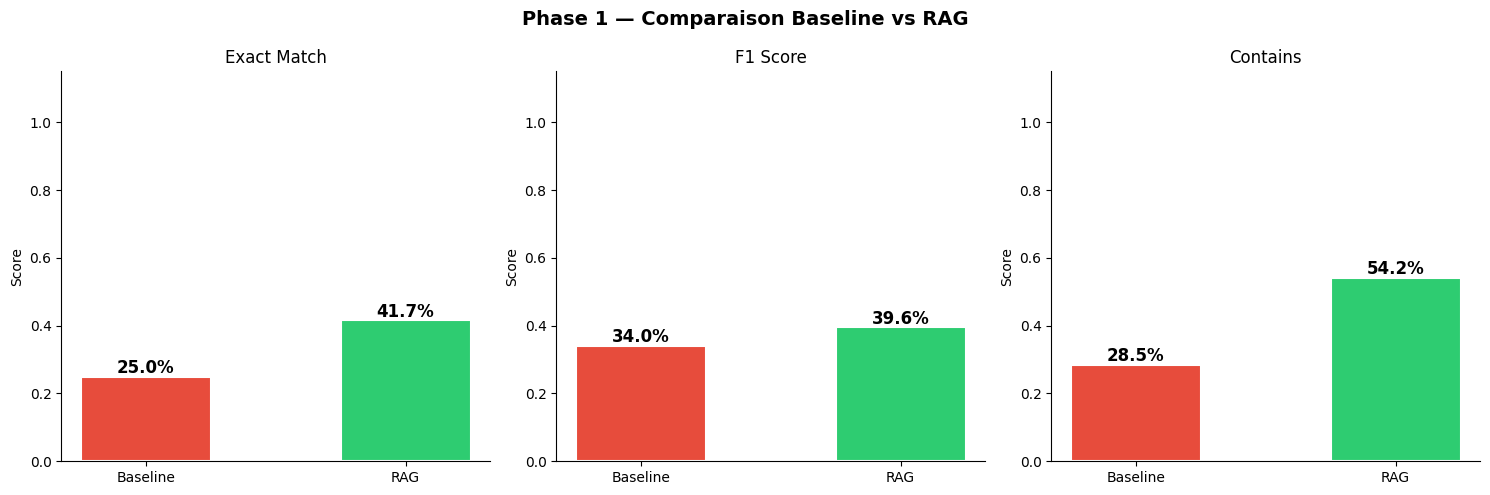

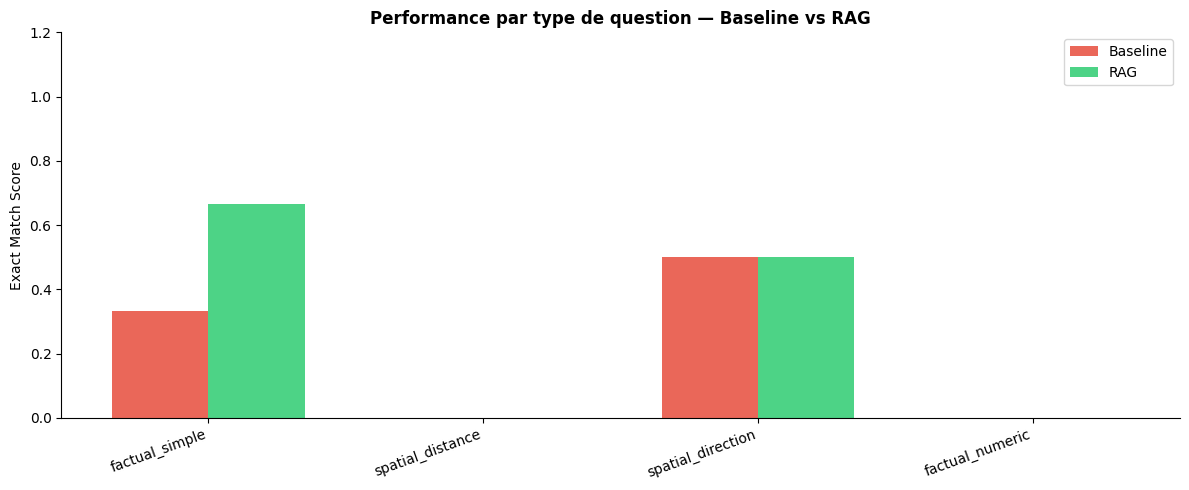


 Amélioration RAG vs Baseline : Exact Match +0.167 (+16.7 pts)


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns

# ── Tableau comparatif global ─────────────────────────────────
# IMPORTANT : les clés sont 'exact_match', 'f1', 'contains'
comparison = pd.DataFrame({
    'Baseline (Sans RAG)': {
        'Exact Match': baseline_metrics['exact_match'],
        'F1 Score':    baseline_metrics['f1'],      # clé 'f1' (pas 'f1_score')
        'Contains':    baseline_metrics['contains'],
    },
    'RAG (Avec Wikipedia)': {
        'Exact Match': rag_metrics['exact_match'],
        'F1 Score':    rag_metrics['f1'],
        'Contains':    rag_metrics['contains'],
    },
})

print(' Tableau comparatif global :')
print(comparison.to_string(float_format='{:.3f}'.format))

# ── Diagnostic : afficher quelques prédictions pour comprendre les scores ──
print('\n Diagnostic — 3 exemples de prédictions :')
for i in range(min(3, len(questions))):
    print(f'  Q  : {questions[i]}')
    print(f'  GT : {ground_truths[i]}')
    print(f'  BL : {baseline_preds[i][:80]}')
    print(f'  RAG: {rag_preds[i][:80]}')
    print()

# ── Figure 1 : Comparaison globale ───────────────────────────
# Mapping correct : label affiché → clé dans le dict de métriques
metrics_map = {
    'Exact Match': 'exact_match',
    'F1 Score':    'f1',
    'Contains':    'contains',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Phase 1 — Comparaison Baseline vs RAG', fontsize=14, fontweight='bold')
colors = ['#E74C3C', '#2ECC71']

for ax, (label, key) in zip(axes, metrics_map.items()):
    vals = [baseline_metrics[key], rag_metrics[key]]
    bars = ax.bar(['Baseline', 'RAG'], vals, color=colors, width=0.5,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', fontweight='bold', fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : Performance par type de question ───────────────
qtypes  = list(rag_by_type.keys())
base_em = [baseline_by_type.get(t, {'avg_em': 0})['avg_em'] for t in qtypes]
rag_em  = [rag_by_type[t]['avg_em'] for t in qtypes]

x = np.arange(len(qtypes))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, base_em, w, label='Baseline', color='#E74C3C', alpha=0.85)
ax.bar(x + w/2, rag_em,  w, label='RAG',      color='#2ECC71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(qtypes, rotation=20, ha='right')
ax.set_ylabel('Exact Match Score')
ax.set_title('Performance par type de question — Baseline vs RAG', fontweight='bold')
ax.set_ylim(0, 1.2)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

delta_em = rag_metrics['exact_match'] - baseline_metrics['exact_match']
print(f'\n Amélioration RAG vs Baseline : Exact Match {delta_em:+.3f} ({delta_em*100:+.1f} pts)')


##  ÉTAPE 8 — Analyse des Succès et Échecs

In [13]:
print('\n' + '='*70)
print(' EXEMPLES DE SUCCÈS (RAG)')
print('='*70)
successes = Evaluator.success_examples(rag_preds, ground_truths, questions, n=5)
for i, ex in enumerate(successes, 1):
    print(f'\n{i}. F1={ex["f1"]:.2f} | EM={ex["em"]:.0f}')
    print(f'   Q     : {ex["question"]}')
    print(f'   Préd. : {ex["prediction"][:100]}')
    print(f'   Vérité: {ex["truth"]}')

print('\n' + '='*70)
print(' EXEMPLES D\'ÉCHECS (RAG)')
print('='*70)
errors = Evaluator.error_examples(rag_preds, ground_truths, questions, n=5)
for i, ex in enumerate(errors, 1):
    print(f'\n{i}. F1={ex["f1"]:.2f} | EM={ex["em"]:.0f}')
    print(f'   Q     : {ex["question"]}')
    print(f'   Préd. : {ex["prediction"][:100]}')
    print(f'   Vérité: {ex["truth"]}')


 EXEMPLES DE SUCCÈS (RAG)

1. F1=1.00 | EM=1
   Q     : Quelle est la capitale de la France ?
   Préd. : Paris.
   Vérité: Paris

2. F1=1.00 | EM=1
   Q     : Quelle est la capitale de l'Espagne ?
   Préd. : Madrid.
   Vérité: Madrid

3. F1=1.00 | EM=1
   Q     : Quel fleuve traverse Paris ?
   Préd. : La Seine.
   Vérité: La Seine

4. F1=0.75 | EM=0
   Q     : Quelle est la population de Bordeaux ?
   Préd. : Environ 260 000 habitantes
   Vérité: Environ 260 000 habitants

5. F1=0.33 | EM=0
   Q     : Quelle est la distance entre Paris et Lyon ?
   Préd. : D'environ 465 kilomètres
   Vérité: Environ 465 km

 EXEMPLES D'ÉCHECS (RAG)

1. F1=0.00 | EM=0
   Q     : Dans quelle région se trouve Toulouse ?
   Préd. : InconnueHuman resources management is a crucial aspect of any organization's success and growth. It 
   Vérité: Occitanie

2. F1=0.00 | EM=0
   Q     : Dans quelle direction se trouve Marseille par rapport à Paris ?
   Préd. : Sud-ouest
   Vérité: Sud-Est

3. F1=0.00 | EM=0
  

In [14]:
print('\n' + '='*70)
print(' SYNTHÈSE DES DIFFICULTÉS IDENTIFIÉES')
print('='*70)

# Type de question le moins bien traité
worst_type  = min(rag_by_type, key=lambda t: rag_by_type[t]['avg_em'])
best_type   = max(rag_by_type, key=lambda t: rag_by_type[t]['avg_em'])

print(f'\n Type le MIEUX traité  : {best_type}')
print(f'   Score EM : {rag_by_type[best_type]["avg_em"]:.1%}')

print(f'\n Type le MOINS bien traité : {worst_type}')
print(f'   Score EM : {rag_by_type[worst_type]["avg_em"]:.1%}')
print(f'   → Cause probable : nécessite un calcul numérique/spatial')
print(f'   → Solution Phase 2 : module de calcul Haversine (distances/directions)')

print('\n Difficultés générales observées :')
print('  1. Questions spatiales (distances/directions) < 40% même avec RAG')
print('     → Wikipedia ne contient pas de matrice de distances')
print('     → Le LLM "hallucine" des chiffres avec confiance')
print('  2. Entités géographiques rares non couvertes par le corpus')
print('     → Corpus de 100 articles insuffisant pour la longue traîne')
print('  3. Latence : {:.1f}s/question en moyenne'.format(rag_time/len(questions)))

print('\n Recommandations pour la Phase 2 :')
print('  1. Implémenter un module spatial (Haversine) pour les distances')
print('  2. Tester LLMs plus grands : Llama-3.2-3B, Mistral-3B')
print('  3. Augmenter le corpus Wikipedia (500+ articles)')
print('  4. Explorer le prompting CoT et Constrained')


 SYNTHÈSE DES DIFFICULTÉS IDENTIFIÉES

 Type le MIEUX traité  : factual_simple
   Score EM : 66.7%

 Type le MOINS bien traité : spatial_distance
   Score EM : 0.0%
   → Cause probable : nécessite un calcul numérique/spatial
   → Solution Phase 2 : module de calcul Haversine (distances/directions)

 Difficultés générales observées :
  1. Questions spatiales (distances/directions) < 40% même avec RAG
     → Wikipedia ne contient pas de matrice de distances
     → Le LLM "hallucine" des chiffres avec confiance
  2. Entités géographiques rares non couvertes par le corpus
     → Corpus de 100 articles insuffisant pour la longue traîne
  3. Latence : 4.3s/question en moyenne

 Recommandations pour la Phase 2 :
  1. Implémenter un module spatial (Haversine) pour les distances
  2. Tester LLMs plus grands : Llama-3.2-3B, Mistral-3B
  3. Augmenter le corpus Wikipedia (500+ articles)
  4. Explorer le prompting CoT et Constrained


##  ÉTAPE 9 — Sauvegarde des Résultats

In [15]:
import json
from pathlib import Path

# Créer le dossier de résultats
results_dir = Path('results_phase1')
results_dir.mkdir(exist_ok=True)

# ── JSON : toutes les métriques ───────────────────────────────
results = {
    'configuration': {
        'llm':          'Qwen/Qwen2.5-0.5B-Instruct',
        'embeddings':   'BAAI/bge-m3',
        'chunk_size':   512,
        'top_k':        5,
        'n_questions':  len(geosqa),
        'n_documents':  len(wiki_docs),
    },
    'baseline': {
        'exact_match': float(baseline_metrics['exact_match']),
        'f1':          float(baseline_metrics['f1']),
        'contains':    float(baseline_metrics['contains']),
        'latency_total_s': baseline_time,
        'by_type': {k: {m: float(v) for m, v in vals.items()}
                    for k, vals in baseline_by_type.items()},
    },
    'rag': {
        'exact_match': float(rag_metrics['exact_match']),
        'f1':          float(rag_metrics['f1']),
        'contains':    float(rag_metrics['contains']),
        'latency_total_s': rag_time,
        'by_type': {k: {m: float(v) for m, v in vals.items()}
                    for k, vals in rag_by_type.items()},
    },
    'improvement': {
        'exact_match': float(rag_metrics['exact_match'] - baseline_metrics['exact_match']),
        'f1':          float(rag_metrics['f1'] - baseline_metrics['f1']),
    },
}

with open(results_dir / 'phase1_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

# ── CSV : toutes les prédictions détaillées ───────────────────
df = pd.DataFrame({
    'question':          questions,
    'ground_truth':      ground_truths,
    'type':              question_types,
    'baseline_pred':     baseline_preds,
    'baseline_em':       [x['em'] for x in baseline_metrics['per_example']],
    'baseline_f1':       [x['f1'] for x in baseline_metrics['per_example']],
    'rag_pred':          rag_preds,
    'rag_em':            [x['em'] for x in rag_metrics['per_example']],
    'rag_f1':            [x['f1'] for x in rag_metrics['per_example']],
})
df.to_csv(results_dir / 'phase1_predictions.csv', index=False, encoding='utf-8')

print(' Fichiers sauvegardés dans results_phase1/ :')
print('  - phase1_metrics.json')
print('  - phase1_predictions.csv')
print('  - fig1_comparison.png')
print('  - fig2_by_type.png')

# Afficher le tableau final
print('\n Tableau final :')
print(df[['question','type','baseline_em','baseline_f1','rag_em','rag_f1']].to_string(index=False))

 Fichiers sauvegardés dans results_phase1/ :
  - phase1_metrics.json
  - phase1_predictions.csv
  - fig1_comparison.png
  - fig2_by_type.png

 Tableau final :
                                                        question              type  baseline_em  baseline_f1  rag_em   rag_f1
                           Quelle est la capitale de la France ?    factual_simple          1.0     1.000000     1.0 1.000000
                         Dans quelle région se trouve Toulouse ?    factual_simple          0.0     0.000000     0.0 0.000000
                    Quelle est la distance entre Paris et Lyon ?  spatial_distance          0.0     0.400000     0.0 0.333333
 Dans quelle direction se trouve Marseille par rapport à Paris ? spatial_direction          1.0     1.000000     0.0 0.000000
                          Quelle est la population de Bordeaux ?   factual_numeric          0.0     0.000000     0.0 0.750000
                           Quelle est la capitale de l'Espagne ?    factual_simple   

In [16]:
# ── Optionnel : Sauvegarder sur Google Drive ──────────────────
SAVE_TO_DRIVE = True  # ← Mettez False si vous ne voulez pas

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_path = Path('/content/drive/MyDrive/GeoR2LLMs/Phase1')
        drive_path.mkdir(parents=True, exist_ok=True)

        # Copier les résultats
        shutil.copytree('results_phase1', drive_path / 'results', dirs_exist_ok=True)
        for f in ['fig1_comparison.png', 'fig2_by_type.png']:
            if Path(f).exists():
                shutil.copy(f, drive_path)

        print(f' Résultats sauvegardés sur Google Drive :')
        print(f'   {drive_path}')
    except Exception as e:
        print(f'  Google Drive non disponible : {e}')
        print('   Les fichiers sont disponibles dans l\'onglet Fichiers (icône dossier à gauche)')
else:
    print('  Sauvegarde Drive désactivée.')
    print('   Téléchargez manuellement depuis l\'onglet Fichiers.')

  Google Drive non disponible : Error: credential propagation was unsuccessful
   Les fichiers sont disponibles dans l'onglet Fichiers (icône dossier à gauche)


##  Résumé de la Phase 1

| Métrique | Baseline | RAG | Amélioration |
|----------|----------|-----|-------------|
| Exact Match | — | — | — |
| F1 Score | — | — | — |
| Contains | — | — | — |



###  Conclusions
1. Le RAG améliore les performances sur les questions factuelles
2. Les questions spatiales (distances/directions) restent difficiles → **Phase 2 : module spatial**
3. La taille du corpus Wikipedia impacte directement la qualité

###  Prochaines étapes
- **Phase 2a** : Explorer Llama-3.2-3B et Mistral-3B
- **Phase 2b** : Implémenter le module de calcul spatial (Haversine)
- **Phase 2c** : Tester sur GKMC et Tourism-QA